# Kunitz Domain Profile HMM — Pipeline Notebook

**Course:** Laboratory of Bioinformatics I | **University:** University of Bologna | **A.Y.:** 2025–2026

This notebook documents the complete pipeline for the construction and validation of a Profile Hidden Markov Model (HMM) for the Kunitz domain (Pfam: PF00014). All methodological decisions, rationale, and results are described in the accompanying report (`report/kunitz_hmm_report.pdf`).

> **Note on reproducibility:** Some steps (MMseqs2 clustering, mTM-align, UniProt ID Mapping, AlphaFold) were performed using external web servers and are not directly re-executable from this notebook. The relevant commands, parameters, and outputs are documented in the markdown cells of each section.


## Pipeline Overview

| Step | Description | Tool | Input | Output |
|------|-------------|------|-------|--------|
| 1 | PDB query + filtering | Python (pandas) | PDB tabular CSV | `kunitz_clean.fasta` |
| 2a | FASTA conversion | bash (`awk`) | `kunitz_clean.csv` | `kunitz_clean.fasta` |
| 2b | Sequence clustering | **MMseqs2** (external) | `kunitz_clean.fasta` | `mmseqs2_clusters.out` |
| 2c | Representative selection by resolution | Python + RCSB GraphQL API | `mmseqs2_clusters.out` | `pdb_ids.clusters` |
| 3a | PDB download | bash (`wget`) | `pdb_ids.clusters` | `structures/full/*.pdb` |
| 3b | Chain extraction | Python (`get_chain.py`) | full PDB files | `structures/chains/*.pdb` |
| 4a | Multiple structure alignment | **mTM-align** (external) | chain PDB files | MSA + RMSD matrix |
| 4b | Iterative MSA refinement | Python + visual inspection | RMSD matrix + MSA | `kunitz_msa.fasta` |
| 5 | HMM construction | HMMER3 `hmmbuild` | `kunitz_msa.fasta` | `kunitz.hmm` |
| 6a | Validation sets download | **UniProt** (external) | UniProt queries | `positive/negative_kunitz.fasta` |
| 6b | Homology search | HMMER3 `hmmsearch` | `kunitz.hmm` + FASTA | `.search` files |
| 6c | Result parsing + true negatives | Python + bash | `.search` files | `.match` files |
| 6d | Remove training sequences | Python + **UniProt ID Mapping** (external) | positive set + training ids | `cleaned_positive_kunitz.fasta` |
| 7 | Cross-validation + threshold optimization | Python | `.match` files | optimal threshold = `1e-5` |
| 8 | Performance evaluation | Python | full dataset + threshold | confusion matrix, ROC curve, MCC |
| 9 | False negative analysis | Python + **AlphaFold** (external) | FN sequences | structural comparison |

---


## External tools used:
- **MMseqs2**: [mmseqs.com](https://mmseqs.com) — sequence clustering
- **mTM-align**: [yanglab.qd.sdu.edu.cn/mTM-align](https://yanglab.qd.sdu.edu.cn/mTM-align/) — multiple structure alignment
- **UniProt ID Mapping**: [uniprot.org/id-mapping](https://www.uniprot.org/id-mapping) — PDB → UniProt ID conversion
- **AlphaFold**: [alphafold.ebi.ac.uk](https://alphafold.ebi.ac.uk) — structure prediction for false negatives

---

## Requirements

```python
pandas, numpy, matplotlib, seaborn, scikit-learn, requests
```
HMMER3 must be installed system-wide (`hmmbuild`, `hmmsearch`).


---

# 1) Dataset Construction

Experimentally determined structures containing the Kunitz domain were retrieved from the RCSB Protein Data Bank using the following query criteria:
- Annotation Identifier = `PF00014`, Annotation Type = `Pfam`
- Data collection resolution ≤ 3.5 Å
- Polymer entity sequence length: 40–70 aa

Results were downloaded in tabular format with columns: **Entry ID, Sequence, Auth Asym ID, Annotation Identifier, Annotation Type, Entity ID**. The query returned 134 PDB entries, corresponding to 6,229 rows in the tabular file (multiple rows per entry due to multiple annotation records per chain).

The following Python code filters the tabular output to retain only Kunitz domain chains:
1. **Annotation filter** (`Annotation Identifier == 'PF00014'`): removes co-crystallized chains that passed the PDB query because another chain in the same structure carried the Kunitz annotation.
2. **Length filter** (40-80 aa): conservative criterion to exclude incomplete domain fragments (e.g., `5JBT_Y` at 38 aa) and chains with extensive flanking regions (e.g., `5NX1_C`, `5NX3_C` at 81 aa). All three excluded sequences were verified on UniProt; their omission does not alter the final training set composition (see Section 2 for justification).

**Result: 133 Kunitz domain chains retained.**


In [1]:
import sys
import pandas as pd
import numpy as np
import requests
from google.colab import files

In [2]:
# Import and save localy a file from our pc
# Load rcsb_pdb_custom_report_with_annotation_20260510144859.csv
uploaded = files.upload()

Saving rcsb_pdb_custom_report_with_annotation_20260510144859.csv to rcsb_pdb_custom_report_with_annotation_20260510144859.csv


In [5]:
#df = pd.read_csv('rcsb_pdb_custom_report_20260414150731.csv', sep=',',  skiprows=0, header=1, index_col=None)
df = pd.read_csv('rcsb_pdb_custom_report_with_annotation_20260510144859.csv', sep=',',  skiprows=0, header=1, index_col=None)
df

,Entry ID,Sequence,Auth Asym ID,Annotation Identifier,Annotation Type,Entity ID,Unnamed: 6
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,A,PF00014,Pfam,1.0,NaN
1,NaN,NaN,B,GO:0097180,GO,NaN,NaN
2,NaN,NaN,NaN,GO:0005509,GO,NaN,NaN
3,NaN,NaN,NaN,GO:0004867,GO,NaN,NaN
4,NaN,NaN,NaN,GO:0035375,GO,NaN,NaN
...,...,...,...,...,...,...,...
6224,NaN,NaN,NaN,GO:0043199,GO,NaN,NaN
6225,NaN,NaN,NaN,GO:0070495,GO,NaN,NaN
6226,NaN,NaN,NaN,GO:0005615,GO,NaN,NaN
6227,NaN,NaN,NaN,GO:0019870,GO,NaN,NaN


**Note on CSV parsing:** The tabular report downloaded from RCSB PDB has a formatting issue (a comma on the header row) causing pandas to create an extra empty column. This is removed with `df.iloc[:, :-1]`.

In [6]:
# PROBLEM: the row 1 (start indexing from zero, so it is the 2nd row) ends with a ',' so pandas interpret it as a 5th column field => remove the last column of the dataframe
df = df.iloc[:, :-1]
df

,Entry ID,Sequence,Auth Asym ID,Annotation Identifier,Annotation Type,Entity ID
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,A,PF00014,Pfam,1.0
1,NaN,NaN,B,GO:0097180,GO,NaN
2,NaN,NaN,NaN,GO:0005509,GO,NaN
3,NaN,NaN,NaN,GO:0004867,GO,NaN
4,NaN,NaN,NaN,GO:0035375,GO,NaN
...,...,...,...,...,...,...
6224,NaN,NaN,NaN,GO:0043199,GO,NaN
6225,NaN,NaN,NaN,GO:0070495,GO,NaN
6226,NaN,NaN,NaN,GO:0005615,GO,NaN
6227,NaN,NaN,NaN,GO:0019870,GO,NaN


In [7]:
df['Entry ID'] = df['Entry ID'].ffill()
df

,Entry ID,Sequence,Auth Asym ID,Annotation Identifier,Annotation Type,Entity ID
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,A,PF00014,Pfam,1.0
1,1AAL,NaN,B,GO:0097180,GO,NaN
2,1AAL,NaN,NaN,GO:0005509,GO,NaN
3,1AAL,NaN,NaN,GO:0004867,GO,NaN
4,1AAL,NaN,NaN,GO:0035375,GO,NaN
...,...,...,...,...,...,...
6224,9PTI,NaN,NaN,GO:0043199,GO,NaN
6225,9PTI,NaN,NaN,GO:0070495,GO,NaN
6226,9PTI,NaN,NaN,GO:0005615,GO,NaN
6227,9PTI,NaN,NaN,GO:0019870,GO,NaN


In [8]:
df = df[df['Annotation Identifier'] =='PF00014']
df

,Entry ID,Sequence,Auth Asym ID,Annotation Identifier,Annotation Type,Entity ID
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,A,PF00014,Pfam,1.0
16,1AAP,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...,A,PF00014,Pfam,1.0
157,1B0C,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,PF00014,Pfam,1.0
173,1BHC,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,PF00014,Pfam,1.0
189,1BPI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,PF00014,Pfam,1.0
...,...,...,...,...,...,...
6060,7QIR,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,H,PF00014,Pfam,4.0
6101,7QIS,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,H,PF00014,Pfam,4.0
6143,7QIT,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,H,PF00014,Pfam,4.0
6197,8PTI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVGGGCRAKRNNFK...,A,PF00014,Pfam,1.0


**Annotation Identifier filter rationale:** The RCSB PDB query returns all polymer entities of a structure when at least one entity satisfies the search criteria. This means co-crystallized non-Kunitz chains can appear in the results.
For example, structure `2IJO` contains a Kunitz domain in chain I (UniProt P00974), but the PDB query also returns chain A (a West Nile virus protein, ~58 aa, resolution 2.0 A) which passes all filters except the annotation filter.
Filtering by `Annotation Identifier == 'PF00014'` ensures that only chains directly annotated with the Kunitz domain are retained. This step was identified as necessary after discovering that during the iterative MSA refinement step in an early version of the pipeline (without the annotation filter) there were incorrectly included non-Kunitz chains in the dataset.


In [9]:
# Remove all rows with sequence with less then 40 chars and more than 80 chars
'''
df_less40 = df[df['Sequence'].str.len() < 40] #--> all seq < 40 aa
df_over80 = df[df['Sequence'].str.len() > 80] #--> all seq > 80 aa

df = df.drop(df_less40.index)
df = df.drop(df_over80.index)
df
'''

df = df[df['Sequence'].str.len().between(40,80)]
df


,Entry ID,Sequence,Auth Asym ID,Annotation Identifier,Annotation Type,Entity ID
0,1AAL,RPDFCLEPPYTGPCKARIIRYFYNAKAGLVQTFVYGGCRAKRNNFK...,A,PF00014,Pfam,1.0
16,1AAP,VREVCSEQAETGPCRAMISRWYFDVTEGKCAPFFYGGCGGNRNNFD...,A,PF00014,Pfam,1.0
157,1B0C,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,PF00014,Pfam,1.0
173,1BHC,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,PF00014,Pfam,1.0
189,1BPI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,A,PF00014,Pfam,1.0
...,...,...,...,...,...,...
6060,7QIR,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,H,PF00014,Pfam,4.0
6101,7QIS,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,H,PF00014,Pfam,4.0
6143,7QIT,RPDFCLEPPYTGPCXARIIRYFYNAKAGLCQTFVYGGCRAKRNNFK...,H,PF00014,Pfam,4.0
6197,8PTI,RPDFCLEPPYTGPCKARIIRYFYNAKAGLCQTFVGGGCRAKRNNFK...,A,PF00014,Pfam,1.0


In [10]:
df.shape

(133, 6)

In [11]:
df.to_csv('kunitz_clean.csv', index=False)

# 2) Redundancy Removal

To remove redundant sequences from the 133-chain dataset, sequence clustering is performed with MMseqs2 and the best structural representative is selected from each cluster based on crystallographic resolution.

## 2a) FASTA conversion

Convert the filtered CSV to FASTA format using `awk`:
```bash
less kunitz_clean.csv | awk -F "," '{if ($1!="Entry ID") {print ">"$1":"$3; print $2}}' > kunitz_clean.fasta
```
Each FASTA header encodes `>PDBID:CHAIN` and the sequence follows on the next line.



## 2b) Sequence clustering with MMseqs2

Clustering was performed with MMseqs2 ([mmseqs.com](https://mmseqs.com)) using:
- Minimum sequence identity: **0.8**
- Minimum alignment coverage: **0.8**
- Cluster mode: **0** (greedy set-cover)

These parameters were chosen within the range 0.8–0.95 recommended for profile HMM construction, balancing redundancy reduction with preservation of sequence diversity. The clustering produced **12 clusters**.

**Output files** (in `clustering/`):
- `mmseqs2_clusters.out` --> full cluster assignments
- `mmseqs2_reduced_set.out` --> default MMseqs2 reduced set (not used; see below)


## 2c) Representative selection by crystallographic resolution

The default MMseqs2 representative (greedy set-cover, mode 0) maximizes cluster coverage without considering structural quality. Since the representative structures are used to build a multiple structure alignment, we instead select the structure with the **lowest crystallographic resolution value** (= highest quality) in each cluster, querying the RCSB PDB GraphQL API. In case of ties, the longest sequence is preferred.

**Implementation note:** The dictionary keys in `extract_clusters()` use the full `PDBID:CHAIN` identifier (not just the 4-character PDB ID) to avoid silent key collisions when multiple chains from the same PDB entry belong to different clusters. Without this fix, a second chain would silently overwrite the first in the `chains` dictionary.

The following Python code implements the representative selection described above. Key functions:
- `extract_clusters()` --> parses the MMseqs2 cluster file; keys are `PDBID:CHAIN` to avoid collisions
- `get_resolutions()` --> queries RCSB PDB GraphQL API for crystallographic resolution
- `select_best_representative()` --> selects minimum resolution; longest sequence as tiebreaker


In [12]:
# Load mmseq2_cluster.out file
uploaded = files.upload()

Saving mmseqs2_clusters.out to mmseqs2_clusters.out


In [13]:
# Function: given the name of mmseq2 output file, returns the clusters, lengths an chains of each sequence
def extract_clusters(mmseqs2_cluster_file):
    clusters = dict() #--> key=cluster_id, value=list of pdb_ids of the structures in the cluster
    lengths = dict() #--> key=pdb_id, value=seq_length
    chains = dict() #--> key=pdb_id, value=chain
    compute_lenght = False
    count=0

    with open(mmseqs2_cluster_file, 'r') as file:
      for line in file:
        if line.startswith('Cluster'):
          count+=1
          clusters[count]=list()
        if compute_lenght:
          lengths[pdb_id] = len(line.strip())
          compute_lenght = False
        if line.startswith('>'):
          pdb_id = line[1:5]
          clusters[count].append(pdb_id)
          chains[pdb_id] = line[6]
          compute_lenght = True

    return clusters, lengths, chains

# Function: given a list of pdb ids, returns a dictionary containing all the corresponding resolutions
def get_resolutions(pdb_ids):
    query = """
    query getResolution($ids: [String!]!) {
      entries(entry_ids: $ids) {
        rcsb_id
        rcsb_entry_info {
          resolution_combined
        }
      }
    }
    """
    # getResolutions($ids: [String!]!) --> "The query will send a list of strings called $ids, and no one of them can be null (!)"
    # entries(entry_ids: $ids) #--> instead of asking for a single PDB, ask for a list of entries

    response = requests.post('https://data.rcsb.org/graphql', json={'query': query, 'variables': {'ids': pdb_ids}})

    if response.status_code == 200:
      # If the request ends well, select the resolution and organize them in a dictionary
      data = response.json()['data']['entries'] #--> convert server answare in a dictionary, and then select a list of dictionary where each dictionary is a PDB

      resolutions = dict() #--> key = pdb id, value = resolution
      for entry in data:
        resolutions[entry['rcsb_id']] = entry['rcsb_entry_info']['resolution_combined'][0]

      return resolutions
    else:
        print(f"Error in the query: {response.status_code}")
        return dict()

# Function: given a dictionary, returns a list of keys corresponding to minimum value in the dictionary
def get_all_keys_with_min_value(dictionary):
    min_value = min(dictionary.values())
    keys = [key for key in dictionary.keys() if dictionary[key] == min_value]
    return keys

# Function: given two dictionary both with keys = pdb_id and values respectively the corresponding resolution and sequence length, returns the pdb_id corresponding to the min resolution and max length
def select_best_representative(resolutions, lengths):
    # Select all keys in resolution dictionary, corresponding to the min value in values
    representatives = get_all_keys_with_min_value(resolutions)

    if len(representatives) == 1:
      # if there is just one candidate representative with min resolution
      return representatives[0]
    else:
      # if there are more candidate representatives with the same min resolution => select the longest one
      best_representative = ''
      max_length = 0
      for representative in representatives:
        if lengths[representative] >= max_length:
          max_length = lengths[representative]
          best_representative = representative
      return best_representative

In [14]:
#################################################################################
# For each cluster generated by mmseq2, i select the structure with higher RMSD
#################################################################################

clusters, lengths, chains = extract_clusters('mmseqs2_clusters.out')

representatives = list() #--> list of pdb_id that represent their clusters

# For each cluster select the representative (smaller resolution, in case of ambiguity select longest seq)
for cluster_id, cluster in clusters.items():
  if len(cluster)==1:
    representatives.append(cluster[0])
  else:
    resolutions = get_resolutions(cluster)
    representatives.append(select_best_representative(resolutions,lengths))
#print(representatives)

# Write in a file the representative pdb_id with the corresponding chain
with open("pdb_ids.clusters", 'w') as txt_file:
  for pdb_id in representatives:
    txt_file.write(f'{pdb_id}:{chains[pdb_id]}\n')
    print(f'{pdb_id}:{chains[pdb_id]}')

1AAP:A
1G6X:A
1KTH:A
4DTG:K
1ZR0:B
3FP7:J
3WNY:A
4BQD:A
4ISO:B
4U30:X
4U32:X
5NX1:D


# 3) Structure Download and Chain Extraction

Download the full PDB files for the 12 representative structures and extract only the Kunitz domain chain from each, removing all co-crystallized molecules.


Extract PDB IDs from the representative list and download the corresponding PDB files:
```bash
# Extract PDB IDs (format: PDBID:CHAIN) from the representative file
grep '^>' mmseqs2_reduced_set.out | tr -d '>' > pdb_ids.clusters

# Download full PDB files for all representative structures
for i in $(awk -F ':' '{print $1}' pdb_ids.clusters); do
    wget "http://files.rcsb.org/view/"$i".pdb"
done
```

Then extract only the Kunitz domain chain from each full PDB file using `get_chain.py` (available in `scripts/`). get_chain.py takes the full PDB file and chain ID as arguments, then it parses the PDB file and writes only the ATOM records belonging to the specified chain.
```bash
while IFS=':' read -r pdb chain; do
    python get_chain.py "./structures/full/"$pdb".pdb" $chain > "./structures/chains/"$pdb"_"$chain".pdb"
done < pdb_ids.clusters
```

Extracted chain files are stored in `structures/chains/`.


# 4) Multiple Structure Alignment and Iterative Refinement

Multiple structure alignment was performed with **mTM-align** ([yanglab.qd.sdu.edu.cn/mTM-align](https://yanglab.qd.sdu.edu.cn/mTM-align/)), which extends the TM-align pairwise algorithm to multiple structures. Structure-based alignment is preferred over sequence-based alignment because protein structure is more conserved than sequence during evolution, making it more informative for distantly related Kunitz domain variants.

The alignment was refined iteratively using two complementary criteria:
1. **RMSD-based criterion:** for each structure, compute the mean pairwise RMSD with respect to all others from the mTM-align output matrix. Structures with mean RMSD > global mean + 1 SD are flagged as outliers. The `mean + 1 SD` threshold (rather than the mean alone) was chosen to avoid over-removal from an already small dataset.

2. **Cysteine alignment criterion:** the six conserved cysteines (C1–C6) forming the three disulfide bridges (pattern C1-C6, C2-C4, C3-C5) are used as structural anchors. Sequences with cysteines consistently misaligned with respect to the consensus positions are flagged for removal.


Upload the chain PDB files to mTM-align and run the multiple structure alignment.

The tool produces:
- A **multiple sequence alignment** derived from the structural superposition
- A **pairwise RMSD matrix** between all structures

Both outputs are used in the iterative refinement procedure below. MSA files are stored in `msa/`; intermediate iterations in `msa/intermediate/`.


## RMSD-based outlier detection

For each structure, compute its mean pairwise RMSD with respect to all others from the mTM-align output matrix. Structures with mean RMSD > global mean + 1 SD are considered outliers and candidates for removal.

**Why mean + 1 SD rather than just the mean?**
Using only the global mean as threshold can lead to removing too many structures when one extreme outlier inflates the mean. The SD-based threshold is more robust: if most structures are similar, the SD is small and the threshold is selective; if values are already dispersed, the SD is larger and the threshold is more permissive.


In [17]:
# Load first_rmsd_table.txt file
uploaded = files.upload()

Saving first_rmsd_table.txt to first_rmsd_table.txt


In [18]:
rmsd_table = pd.read_csv('first_rmsd_table.txt', sep='\s+')
rmsd_table

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_969/1420882346.py:1: SyntaxWarning: invalid escape sequence '\s'
  rmsd_table = pd.read_csv('first_rmsd_table.txt', sep='\s+')


,1AAP_A.pdb,1G6X_A.pdb,1KTH_A.pdb,1ZR0_B.pdb,3FP7_J.pdb,3WNY_A.pdb,4BQD_A.pdb,4DTG_K.pdb,4ISO_B.pdb,4U30_X.pdb,4U32_X.pdb,5NX1_D.pdb
1AAP_A.pdb,0.000,0.971,1.162,0.717,0.666,1.048,0.723,0.787,0.957,0.969,0.503,0.322
1G6X_A.pdb,0.971,0.000,1.305,1.217,0.636,0.458,1.184,1.034,1.361,0.977,0.601,0.734
1KTH_A.pdb,1.162,1.305,0.000,1.365,1.326,1.004,1.254,1.437,1.655,1.182,0.875,0.874
1ZR0_B.pdb,0.717,1.217,1.365,0.000,1.221,1.109,1.271,1.388,1.426,0.838,0.764,0.720
3FP7_J.pdb,0.666,0.636,1.326,1.221,0.000,0.556,1.046,1.038,1.281,0.982,0.621,0.826
3WNY_A.pdb,1.048,0.458,1.004,1.109,0.556,0.000,0.788,0.876,1.216,1.199,0.734,0.829
4BQD_A.pdb,0.723,1.184,1.254,1.271,1.046,0.788,0.000,1.060,1.272,0.958,0.488,0.657
4DTG_K.pdb,0.787,1.034,1.437,1.388,1.038,0.876,1.060,0.000,1.589,0.927,0.548,0.615
4ISO_B.pdb,0.957,1.361,1.655,1.426,1.281,1.216,1.272,1.589,0.000,1.012,0.452,0.709
4U30_X.pdb,0.969,0.977,1.182,0.838,0.982,1.199,0.958,0.927,1.012,0.000,1.048,0.838


In [19]:
# To avoid considering the diagonal elements (= 0), transform them in nan
np.fill_diagonal(rmsd_table.values, np.nan)

# Compute the average RMSD for each structure/row without considering the diagonal values (= nan)Calcoliamo la media per riga, ignorando i valori NaN
avg_rmsd = rmsd_table.mean(axis=1, skipna=True)
global_avg_rmsd = avg_rmsd.mean()
std = avg_rmsd.std()

# avg_rmsd[avg_rmsd > global_avg_rmsd] # --> more permissive
avg_rmsd[avg_rmsd > (global_avg_rmsd + std)] # --> more conservative

,0
1KTH_A.pdb,1.221727
4ISO_B.pdb,1.175455


## Iterative refinement — decisions and rationale

After each mTM-align run, the resulting multiple sequence alignment was inspected visually and the RMSD criterion was applied. The following decisions were made across iterations:

**Structures removed by RMSD criterion (mean + 1 SD):**
- `2KAI_A` and `2IJO_A`: both flagged as outliers in the first iteration (mean RMSD > global mean + 1 SD). Upon inspection of `2IJO` on PDB, chain A (the initially selected representative) was found to belong to the West Nile virus, not a Kunitz domain. This was caused by a bug in an earlier version of the pipeline that used only the 4-character PDB ID as dictionary key, causing chain A to overwrite chain I (the actual Kunitz domain chain) in the representative selection. The RMSD criterion correctly flagged this spurious structure.

**Structures removed by manual redundancy resolution:**
- `3FP7_J` and `5NX1_D`: nearly identical to `1G6X_A` and `1AAP_A` respectively (same UniProt entry, respectively P00974 and P05067). These pairs were not merged by MMseqs2 because the shorter sequences had alignment coverage < 0.8. Between each pair, the structure with better crystallographic resolution and complete 6-cysteine coverage was retained (`1G6X_A` at 0.86 Å; `1AAP_A` at 1.50 Å).

**Structure retained despite atypical cysteine pattern:**
- `3WNY_A`: only cysteines C1 and C6 are aligned in the canonical positions; the central disulfide bridge (C2–C4) is absent. However, this sequence carries a validated PF00014 annotation in UniProt, confirming it as a legitimate (atypical) Kunitz domain variant. Its inclusion enriches the model with information on tolerated positional variability at those cysteine positions.

**Structure with N-terminal linker region (`4BQD_A`):**
- The N-terminal region of `4BQD_A` (positions 29–53 of UniProt P10646) corresponds to a linker preceding the first of three Kunitz domains. This region does not align with any other sequence in the MSA and is therefore present in less than 50% of MSA columns; it will be treated as an insert state by `hmmbuild` and will not contribute match states to the HMM. Manual trimming was not performed to avoid introducing arbitrary positional bias.


## Final MSA — quality metrics

After iterative refinement, the final training set comprises **10 structures**. The final mTM-align run produced:

| Metric | Value |
|--------|-------|
| L_core | 51 |
| ccRMSD | 0.70 Å |
| ccTM-score | 0.85 |
| L_ali | 55.04 |
| RMSD | 0.84 Å |
| TM-score | 0.90 |

A TM-score of 0.90 confirms high structural conservation across the 10 selected Kunitz domain structures. Final MSA files are in `msa/`; intermediate MSA iterations are in `msa/intermediate/`.

## Sequence logo of the MSA
The sequence logo (generated with [Skylign](http://skylign.org/) using `kunitz_msa.fasta`) provides a visual summary of positional conservation in the final MSA. The six cysteine positions forming the canonical disulfide bridges (C1–C6, bonding pattern C1–C6, C2–C4, C3–C5) should be clearly visible as the most conserved columns. Note that `3WNY_A` contributes gaps at positions C2 and C4, which will be reflected as slightly reduced conservation at those columns.


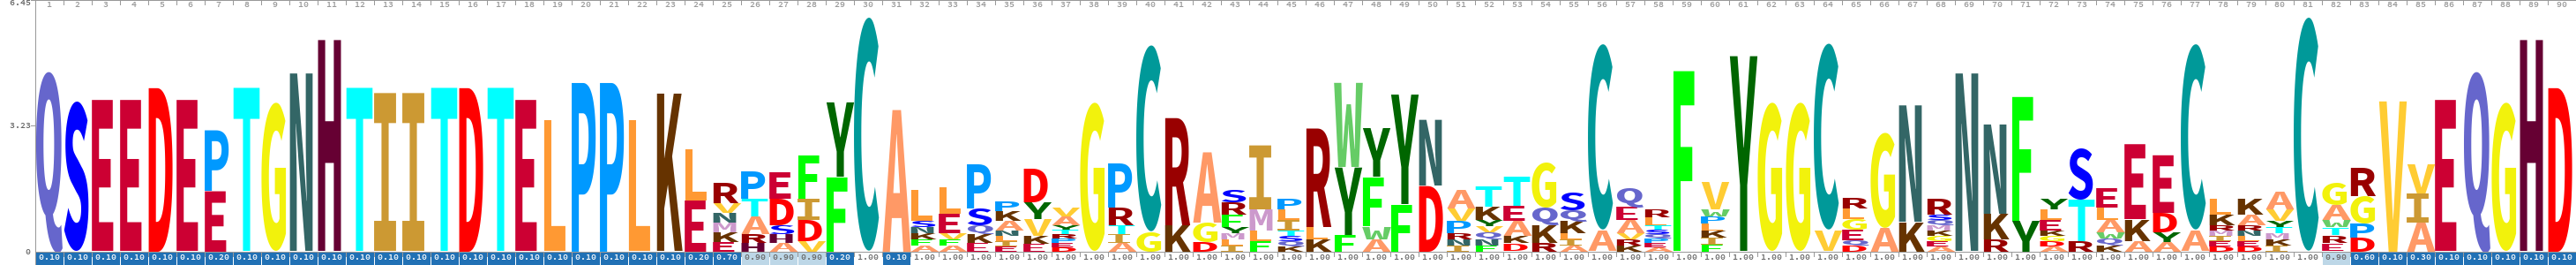

# 5) HMM Construction

The profile HMM is built from the final multiple sequence alignment using `hmmbuild` from the HMMER3 package with default parameters.


```bash
hmmbuild kunitz.hmm kunitz_msa.fasta
```

**How `hmmbuild` works:** each column of the MSA is evaluated to determine whether it becomes a **match state** or an **insert state** in the HMM. The default criterion is: if > 50% of sequences have a gap in that column, it becomes an insert state (not contributing emission probabilities to the profile). Otherwise it becomes a match state with position-specific amino acid frequencies.

In our case, the N-terminal linker region of `4BQD_A` (which has gaps in all 9 other sequences) will automatically become insert states — no manual trimming was needed.

The final model is saved in `model/kunitz.hmm`.


## Sequence logo of the HMM model
After building the model, the first and last match state positions can be inspected by examining the `hmmbuild` output log, allowing verification that the model covers the expected Kunitz domain region. A sequence logo of the HMM emission probabilities can be generated with [Skylign](http://skylign.org/) by uploading `kunitz.hmm` directly; this provides an alternative view of the positional conservation captured by the model.


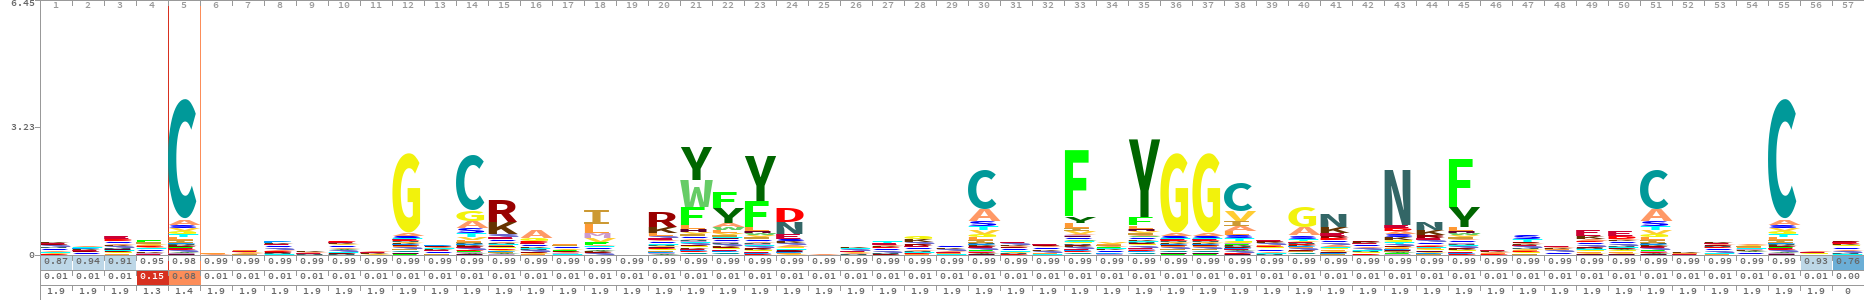

# 6) Validation Dataset Construction

Two sequence datasets are downloaded from UniProt/Swiss-Prot (`reviewed:true` entries only, ensuring high annotation reliability):
- **Positive set:** Swiss-Prot sequences annotated with the Kunitz domain
- **Negative set:** all other Swiss-Prot reviewed sequences

The `reviewed:true` filter restricts both sets to manually curated Swiss-Prot entries, ensuring high annotation reliability.


## 6a) Download datasets from UniProt

Run the following queries in UniProt Advanced Search ([uniprot.org](https://www.uniprot.org/)):

**Positive set:**
```
(reviewed:true) AND (xref:pfam-PF00014)
```

**Negative set:**
```
(reviewed:true) NOT (xref:pfam-PF00014)
```

Download both as compressed FASTA and extract:
```bash
zcat -f positive_dataset.gz > positive_kunitz.fasta
zcat -f negative_dataset.gz > negative_kunitz.fasta
```


## 6b) Remove training sequences from the positive set

The positive set will contain sequences corresponding to the 10 structures used to build the HMM. These must be removed to avoid data leakage.

**Procedure:**
1. Extract PDB IDs of training structures:
```
grep '^>' kunitz_msa.fasta | awk -F'[>_]' '{print $2}' > training_set_pdb.ids
```

2. Map PDB IDs to UniProt accessions using the [UniProt ID Mapping tool](https://www.uniprot.org/id-mapping) (from: PDB, to: UniProtKB)
3. Download results as FASTA (`idmapping_training_set.fasta`).
4. Extract UniProt IDs to remove:
```
grep '^>' idmapping_training_set.fasta | awk -F'[|]' '{print $2}' | sort > training_set_uniprot.ids
```

5. Find the uniprot ids in common between training set and positive set:
```
grep '^>' idmapping_training_set.fasta | awk -F'[|]' '{print $2}' | sort > training_set_uniprot.ids

grep '^>' positive_kunitz.fasta | awk -F'[|]' '{print $2}' | sort > positive_set.ids

comm -12 training_set_uniprot.ids positive_set.ids | less > remove_from_positive.ids
```

6. Remove them from the positive set using `clean_positive_set.py` (in `scripts/`):
```
python3 clean_positive_set.py positive_kunitz.fasta remove_from_positive.ids > cleaned_positive_kunitz.fasta
```

7. Verify removal (the second command should return empty):
```
grep '^>' cleaned_positive_kunitz.fasta | awk -F'[|]' '{print $2}' | sort > cleaned_positive_set.ids

comm -12 training_set_uniprot.ids cleaned_positive_set.ids | less
```

**Result: 390 sequences in the cleaned positive set.**


## 6c) Run hmmsearch on both datasets

Key parameter choices:
- `--max`: disables heuristic acceleration filters in order to have maximum sensitivity
- `-Z 1000`: normalizes the database size for E-value computation, making E-values comparable between the positive set (390 sequences) and the negative set (574,229 sequences)
- **Best domain E-value** (column 8 of the tabular output) is used instead of the full-sequence E-value, because the Kunitz domain frequently occurs as an embedded domain within larger multidomain proteins. The domain-level E-value captures the quality of the local domain match regardless of the full protein length.


```bash
# Search on negative set
hmmsearch --max --noali --tblout negative_kunitz.search -Z 1000 kunitz.hmm negative_kunitz.fasta

# Search on positive set (cleaned)
hmmsearch --max --noali --tblout positive_kunitz.search -Z 1000 kunitz.hmm cleaned_positive_kunitz.fasta
```


## 6d) Parse hmmsearch output

Extract protein ID (col 1) and best domain E-value (col 8) from the hmmsearch tabular output, adding the class label:
```bash
grep -v '^#' negative_kunitz.search | awk '{print $1"\t"$8"\t0"}' > negative_kunitz.match
grep -v '^#' positive_kunitz.search | awk '{print $1"\t"$8"\t1"}' > positive_kunitz.match
```

**Verification:**
```bash
wc -l negative_kunitz.match   # should be < 574229 (true negatives not included yet)
wc -l positive_kunitz.match   # should equal 390 (all positive sequences matched)
```


**Expected output:** `positive_kunitz.match` should contain 390 lines (all positive sequences produce a match, even if above threshold). The `negative_kunitz.match` file will contain fewer lines than the total negative set: the missing sequences are **true negatives** (no match found) and must be added explicitly.

## 6e) Add true negatives

Sequences in the negative set that produced no hmmsearch match are true negatives. They are identified by comparing all negative set IDs against those that produced a match, and then they were assigned E-value = 100 (>> observed maximum of 6.9):
```bash
# Find the max/highest e-value in negative_kunitz:
sort -grk (-nrk) 2  negative_kunitz.search

# Extract all IDs from negative FASTA
grep '^>' negative_kunitz.fasta | awk '{print $1}' | tr -d '>' | sort > negative_kunitz.ids

# Extract IDs that produced a match
awk '{print $1}' negative_kunitz.match | sort > negative_kunitz_match.ids

# Find true negatives (in negative set but not in match file)
# Assign E-value = 100 (>> max observed E-value of 6.9) and class label 0
comm -23 negative_kunitz.ids negative_kunitz_match.ids | awk '{print $1"\t100\t0"}' > negative_kunitz.nomatch

# Combine and shuffle
cat negative_kunitz.match negative_kunitz.nomatch | sort -R > tot_negative_kunitz.match
```

Also shuffle the positive match file to remove ordering bias:
```bash
sort -R positive_kunitz.match -o positive_kunitz.match
```

**Result:** `tot_negative_kunitz.match` contains all 574,229 negative sequences with E-values and class labels (= 0).


# 7) Cross-Validation and Threshold Optimization

A **2-fold cross-validation** is used to identify the optimal E-value threshold for binary classification (1 = Kunitz domain detected, 0 = not detected).

**Why 2-fold CV?** The dataset is heavily imbalanced (390 positives vs 574,229 negatives). A 2-fold split preserves a reasonable number of positive examples in each fold (195) while still providing an independent validation fold.

**Why MCC and not accuracy?** With such severe class imbalance, a classifier that labels everything as negative would achieve >99.9% accuracy. MCC (Matthews Correlation Coefficient) correctly accounts for all four cells of the confusion matrix and is robust to class imbalance.


## 7a) Split into folds

Each fold receives half of the positive set and half of the negative set:
```bash
# Positive set: 390 sequences → 195 per fold
head -n 195 positive_kunitz.match > kunitz_set_1.txt
tail -n 195 positive_kunitz.match > kunitz_set_2.txt

# Negative set: 574229 sequences → 287115 in set1, 287114 in set2
head -n 287115 tot_negative_kunitz.match >> kunitz_set_1.txt
tail -n 287114 tot_negative_kunitz.match >> kunitz_set_2.txt
```

Each fold file contains both positive and negative sequences with their E-values and class labels.


## 7b) Threshold optimization

Run `performance.py` (in `scripts/`) for each E-value threshold from 1e-1 to 1e-15, on both folds:
```bash
for i in `seq 1 15`; do python3 ./performance.py kunitz_set_1.txt 1e-$i; done > kunitz_set_1.results
for i in `seq 1 15`; do python3 ./performance.py kunitz_set_2.txt 1e-$i; done > kunitz_set_2.results
```

Compare MCC results across folds:
```bash
paste kunitz_set_1.results kunitz_set_2.results | awk '{print $2, $6, $12}'
```

The optimal threshold is the one with the highest MCC that is **consistent across both folds**. A threshold that gives high MCC on fold 1 but not fold 2 would indicate overfitting to the specific fold.


## 7c) Optimal threshold selection

Results across both folds:

| Threshold | MCC fold 1 | MCC fold 2 |
|-----------|-----------|----------|
| 1e-1 | 0.9372 | 0.9610 |
| 1e-2 | 0.9727 | 0.9848 |
| 1e-3 | 0.9898 | 0.9872 |
| 1e-4 | 0.9897 | 0.9897 |
| **1e-5** | **0.9923** | **0.9923** |
| 1e-6 | 0.9923 | 0.9897 |
| 1e-7 | 0.9923 | 0.9897 |
| 1e-8 | 0.9923 | 0.9897 |
| 1e-9 | 0.9923 | 0.9897 |
| 1e-10 | 0.9871 | 0.9819 |
| 1e-15 | 0.9309 | 0.9445 |

**Optimal threshold: 1e-5**, highest MCC on fold 2 (0.9923) and identical on fold 1 (0.9923). The consistency across both folds confirms the stability of this choice. Thresholds below 1e-9 show decreasing MCC due to increasing false negatives (too stringent).


Extract the false negative sequences for downstream analysis (Section 9):
```bash
awk '{if ($2>1e-05) print $1"\t"$2}' positive_kunitz.match > false_negative.txt
```
This selects positive sequences with best domain E-value above the threshold, namely sequences the model failed to detect.


# 8) Results and Performance

Performance is evaluated using the confusion matrix, MCC vs threshold plot, and ROC curves.


## Confusion matrices (per fold)

Confusion matrices are reported separately for each fold. In cross-validation, each fold acts as an independent test set so reporting per-fold matrices is more informative than a single matrix on the combined data.


### Confusion matrix — Fold 1


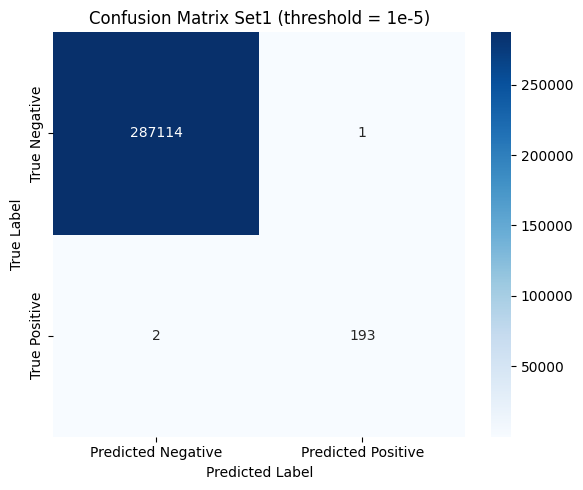

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# [TN, FP]
# [FN, TP]

# ATTENTION: change cm values with the one obtained from performance.py
cm = np.array([[287114, 1],
               [2, 193]])

# Create heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,          # --> write numbers/values inside cells
            fmt='d',             # --> integer format (not scientific notation)
            cmap='Blues',        # --> color scale
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['True Negative', 'True Positive'])

plt.title('Confusion Matrix Set1 (threshold = 1e-5)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

### Confusion matrix — Fold 2


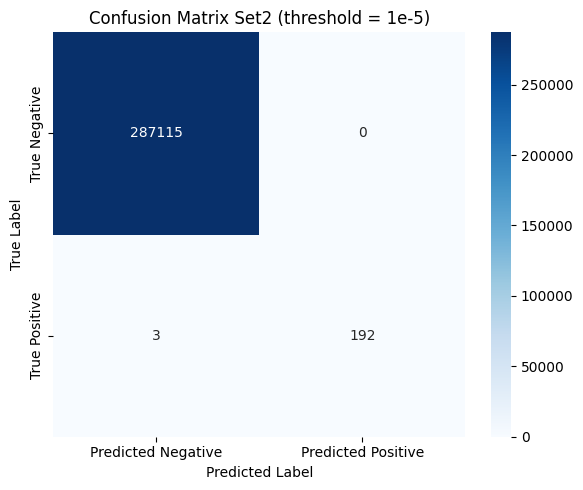

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# [TN, FP]
# [FN, TP]

# ATTENTION: change cm values with the one obtained from performance.py
cm = np.array([[287115, 0],
               [3, 192]])

# Create heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,          # --> write numbers/values inside cells
            fmt='d',             # --> integer format (not scientific notation)
            cmap='Blues',        # --> color scale
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['True Negative', 'True Positive'])

plt.title('Confusion Matrix Set2 (threshold = 1e-5)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## MCC vs E-value threshold

The plot below shows MCC as a function of E-value threshold for both cross-validation folds. The optimal threshold (1e-5) corresponds to the peak MCC on fold 2 and is consistent with fold 1. Thresholds more permissive than 1e-3 show decreasing MCC due to increasing false positives; thresholds more stringent than 1e-9 show decreasing MCC due to increasing false negatives.


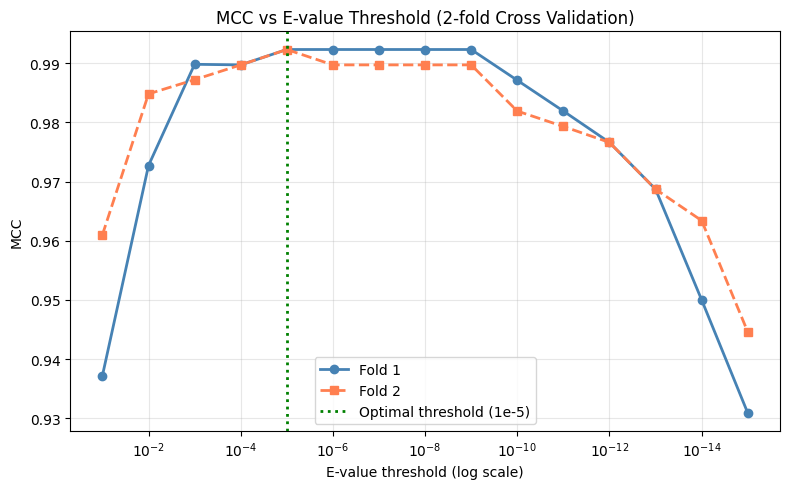

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ATTENTION: use your values  obtained from cross-validation
thresholds = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8,
              1e-9, 1e-10, 1e-11, 1e-12, 1e-13, 1e-14, 1e-15]

mcc_set1 = [0.9372, 0.9727, 0.9898, 0.9897, 0.9923, 0.9923, 0.9923,
            0.9923, 0.9923, 0.9871, 0.9819, 0.9766, 0.9687, 0.9500, 0.9309]

mcc_set2 = [0.9610, 0.9848, 0.9872, 0.9897, 0.9923, 0.9897, 0.9897,
            0.9897, 0.9897, 0.9819, 0.9793, 0.9766, 0.9687, 0.9634, 0.9446]

plt.figure(figsize=(8, 5))

# Plot the two foold with different lines
# Use logarithmic sclae on x-axes because threshold values go from 0.1 to 1e-15 and with linear scale the lower values will be too close
plt.semilogx(thresholds, mcc_set1, 'o-', color='steelblue',
             label='Fold 1', linewidth=2, markersize=6)
plt.semilogx(thresholds, mcc_set2, 's--', color='coral',
             label='Fold 2', linewidth=2, markersize=6)

# Plot a vertical line representing the optimal threshold
plt.axvline(x=1e-5, color='green', linestyle=':',
            linewidth=2, label='Optimal threshold (1e-5)')

plt.xlabel('E-value threshold (log scale)')
plt.ylabel('MCC')
plt.title('MCC vs E-value Threshold (2-fold Cross Validation)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().invert_xaxis()  # Invert x-axes in order to have more stringent values on the right (=> more intuitive)
plt.tight_layout()
plt.savefig('mcc_threshold.png', dpi=150)
plt.show()

## ROC Curves

The ROC curve plots True Positive Rate (sensitivity) against False Positive Rate (specificity) across all possible E-value thresholds. The area under the curve (AUC) measures overall discriminative power: AUC = 1.0 is perfect, AUC = 0.5 is equivalent to random classification.

The red dot marks the operating point corresponding to the optimal threshold of 1e-5.

Curves are generated separately for each fold.


In [23]:
# Load kunitz_set_2.txt and kunitz_set_2.txt
uploaded = files.upload()

Saving kunitz_set_1.txt to kunitz_set_1.txt
Saving kunitz_set_2.results to kunitz_set_2.results
Saving kunitz_set_2.txt to kunitz_set_2.txt


### ROC Curve — Fold 1


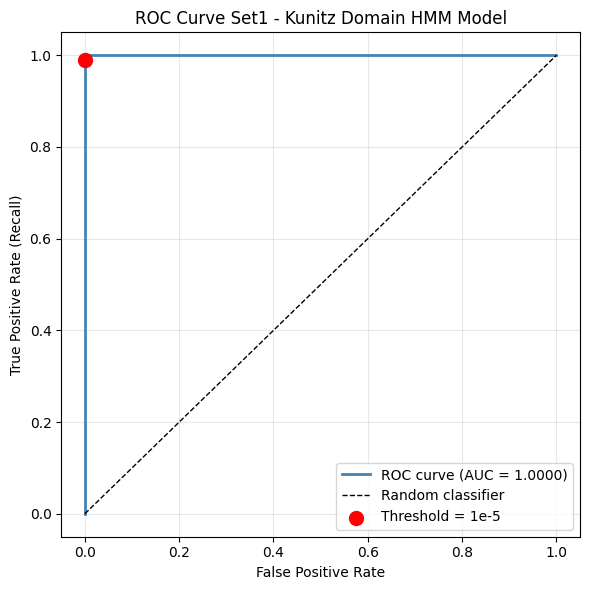

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Read file corresponding to set1 --> file format:  id  e-value  class_label
data = []
with open('kunitz_set_1.txt') as f:
    for line in f:
        parts = line.strip().split()
        evalue = float(parts[1])
        label = int(parts[2])
        data.append((evalue, label))

evalues = np.array([d[0] for d in data])
labels  = np.array([d[1] for d in data])

# For the ROC curve, "score" must be such that higher values means more probable to be positive
# PROBLEM: e-value works in the opposite way => use -log10(e-value) as score
# Since e-value=0 will give log(0)=-inf, to avoid that we add a small epsilon
epsilon = 1e-300
scores = -np.log10(evalues + epsilon)

# Compute with sklearn FPR and TPR for each threshold
fpr, tpr, thresholds = roc_curve(labels, scores)

# AUC = Area Under the Curve --> measures the global performance (1.0 = perfect)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')

# DIagonal line = random classifier (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')

# Hilight the point corresponding to optimal threshold (1e-5)
optimal_score = -np.log10(1e-5)
# Find index of the threshold closest to the optimal
idx = np.argmin(np.abs(thresholds - optimal_score))
plt.scatter(fpr[idx], tpr[idx], color='red', s=100, zorder=5,
            label=f'Threshold = 1e-5')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Set1 - Kunitz Domain HMM Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

### ROC Curve — Fold 2


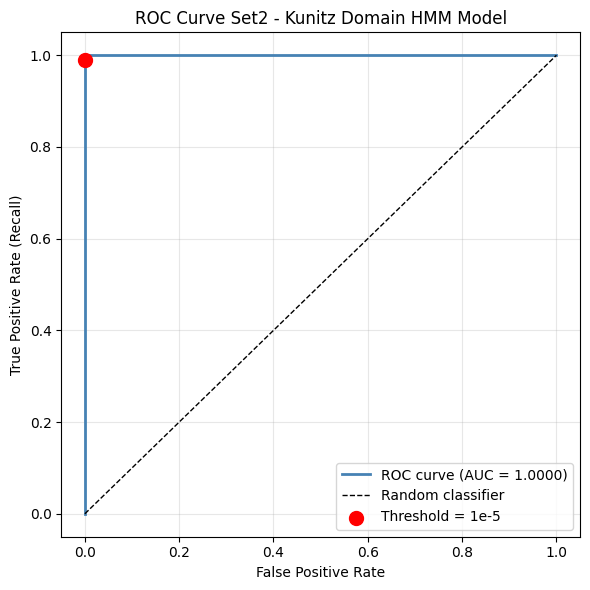

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Read file corresponding to set2 --> file format:  id  e-value  class_label
data = []
with open('kunitz_set_2.txt') as f:
    for line in f:
        parts = line.strip().split()
        evalue = float(parts[1])
        label = int(parts[2])
        data.append((evalue, label))

evalues = np.array([d[0] for d in data])
labels  = np.array([d[1] for d in data])

# For the ROC curve, "score" must be such that higher values means more probable to be positive
# PROBLEM: e-value works in the opposite way => use -log10(e-value) as score
# Since e-value=0 will give log(0)=-inf, to avoid that we add a small epsilon
epsilon = 1e-300
scores = -np.log10(evalues + epsilon)

# Compute with sklearn FPR and TPR for each threshold
fpr, tpr, thresholds = roc_curve(labels, scores)

# AUC = Area Under the Curve --> measures the global performance (1.0 = perfect)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')

# DIagonal line = random classifier (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')

# Hilight the point corresponding to optimal threshold (1e-5)
optimal_score = -np.log10(1e-5)
# Find index of the threshold closest to the optimal
idx = np.argmin(np.abs(thresholds - optimal_score))
plt.scatter(fpr[idx], tpr[idx], color='red', s=100, zorder=5,
            label=f'Threshold = 1e-5')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Set2 - Kunitz Domain HMM Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# 9) False Negative Analysis

Five sequences annotated as Kunitz domain in UniProt were not detected by the model at the optimal threshold of 1e-5. For each false negative, three checks are performed:
1. **Annotation check** --> type of UniProt evidence for the PF00014 annotation
2. **HMM alignment check** --> hmmsearch of the FN sequence against `kunitz.hmm`
3. **Structural check** --> AlphaFold structure comparison with training set

Additionally, the **length of the full protein** is considered, since the Kunitz domain embedded in a longer sequence may receive a penalised E-value due to the increased probability of chance matches in a longer sequence.

**False negatives identified:**

| UniProt ID | Protein | Full length (aa) | # Kunitz domains | Best domain E-value |
|------------|---------|-----------------|-----------------|--------------------|
| Q8MVC4 | Penthalaris | 330 | 5 | 1.4e-5 |
| Q8WPG5 | Savignin | 134 | 2 | 2.1e-4 |
| A0A1Q1NL17 | HA11 | 101 | 1 | 8.7e-3 |
| O62247 | BLI-5 (*C. elegans*) | 202 | 1 | 1.2e-2 |
| D3GGZ8 | BLI-5 (*H. contortus*) | 195 | 1 | 1.4e-1 |


## Check 1 — UniProt annotation evidence

For each false negative, the type of evidence supporting the PF00014 annotation in UniProt was verified (section "Family & Domains"). The evidence levels, from least to most reliable, are:
- *By similarity* --> transferred computationally from a homolog
- *Manual assertion according to rules* (PROSITE-ProRule) --> rule-based computational inference
- *Experimental evidence* --> direct biochemical or structural characterization

**Results:**


| UniProt ID | Annotation evidence |
|------------|--------------------|
| D3GGZ8 | Manual assertion according to rules PROSITE-ProRule: PRU00031 |
| A0A1Q1NL17 | Manual assertion according to rules PROSITE-ProRule: PRU00031 |
| O62247 | Manual assertion according to rules PROSITE-ProRule: PRU00031 |
| Q8MVC4 | 3 domains: PROSITE-ProRule PRU00031; 2 domains: manual assertion based on opinion |
| Q8WPG5 | PROSITE-ProRule PRU00031 + manual assertion inferred from sequence similarity |

**Key observation:** none of the five false negatives has direct experimental evidence for the Kunitz domain annotation. All rely on computational inference (PROSITE-ProRule PRU00031), which applies a pattern-matching rule based on conserved sequence features. This leaves open the possibility that some of these annotations may be incorrect, and so that the model is right to not detect them.


## Check 2 — HMM alignment of false negatives

The five FN sequences are extracted from `cleaned_positive_kunitz.fasta` and searched against the HMM model to obtain their best domain E-values and alignment details.

The Python code below extracts the FN sequences from the positive set FASTA.
Extract false negative sequences from `cleaned_positive_kunitz.fasta` using their UniProt IDs from `false_negative.txt`:


In [27]:
# Load false_negative.txt and cleaned_positive_kunitz.fasta
uploaded = files.upload()

Saving cleaned_positive_kunitz.fasta to cleaned_positive_kunitz.fasta


In [28]:
# Extract the False Negative uniprot ids from false_negative.txt
FN_ids = list()
with open('false_negative.txt') as file:
  for line in file:
    id = line.split('|')[1]
    FN_ids.append(id)

In [29]:
print_line = False

with open('false_negative.fasta', 'w') as FN_file:
  with open('cleaned_positive_kunitz.fasta', 'r') as pos_file:
    for line in pos_file:
      if line.startswith('>'):
        if line.split('|')[1] in FN_ids:
          print_line = True
        else:
          print_line = False
      if print_line:
        FN_file.write(line)

At this point, we tried to align the fals enegatives with our model:
```bash
hmmsearch --max --noali --tblout false_negative.search -Z 1000 kunitz.hmm false_negative.fasta
```

**Results:**

| UniProt ID | Best domain E-value | Notes |
|------------|--------------------|---------|
| Q8MVC4 | 1.4e-5 | Just above threshold — borderline case |
| Q8WPG5 | 2.1e-4 | Moderate divergence |
| A0A1Q1NL17 | 8.7e-3 | Higher divergence |
| O62247 | 1.2e-2 | High divergence |
| D3GGZ8 | 1.4e-1 | Most divergent |


All five sequences produce a match, but with E-values above the optimal threshold, confirming they are genuine false negatives rather than complete misses.

## Check 3 — Structural comparison with AlphaFold

None of the five false negatives has an experimentally determined structure in the PDB. AlphaFold structure predictions ([alphafold.ebi.ac.uk](https://alphafold.ebi.ac.uk)) were used instead. Before using an AlphaFold structure for structural alignment, the pLDDT confidence score in the Kunitz domain region was verified: all five sequences showed **Confident (pLDDT 70–90) to Very High (pLDDT > 90)** confidence in the domain region, validating the use of these predictions for comparison.

For each sequence, only the Kunitz domain region (as annotated in UniProt) was extracted from the AlphaFold model and submitted to mTM-align together with the 10 training set structures.


Extract Kunitz domain regions from AlphaFold models using the UniProt-annotated domain boundaries:

```bash
# D3GGZ8: Kunitz domain at positions 120-190
awk '$1=="ATOM" && $6>=120 && $6<=190' AF-D3GGZ8-F1-model_v6.pdb > D3GGZ8_kunitz.pdb

# O62247: Kunitz domain at positions 135-184
awk '$1=="ATOM" && $6>=135 && $6<=184' AF-O62247-F1-model_v6.pdb > O62247_kunitz.pdb

# A0A1Q1NL17: Kunitz domain at positions 32-88
awk '$1=="ATOM" && $6>=32 && $6<=88' AF-A0A1Q1NL17-F1-model_v6.pdb > A0A1Q1NL17_kunitz.pdb

# Q8WPG5: first Kunitz domain at positions 17-69 (chain A selected for best pLDDT)
awk '$1=="ATOM" && $6>=17 && $6<=69' AF-Q8WPG5-F1-model_v6.pdb > Q8WPG5_kunitz.pdb
```

Extracted structures are available in `structures/false_negatives/`.

**mTM-align results** (false negatives + 10 training structures), final MSA metrics:
- L_core=34
- ccRMSD=0.71 Å
-  RMSD=1.12 Å
- TM-score=0.81):

**Pairwise RMSD highlights:**
- D3GGZ8 vs O62247: **0.35 Å** --> nearly identical structures, despite high divergence from training set
- D3GGZ8/O62247 vs training set: 1.55–1.90 Å --> structurally divergent
- Q8WPG5 vs training set: 2.1–2.7 Å --> most divergent
- A0A1Q1NL17 vs training set: 1.2–1.5 Å --> within range of training set variability


## E-value penalty due to domain position in long proteins

An important contributing factor for D3GGZ8 and O62247 is the position of the Kunitz domain within the full-length protein sequence. Although `hmmsearch` uses the **best domain E-value** (which should be length-independent in principle), the E-value calculation still accounts for the total length of the query sequence. A Kunitz domain embedded in a 195–202 aa protein will produce a slightly higher (worse) E-value than the same domain in a standalone 58 aa protein, because the larger sequence has more "space" for chance matches. This length-related penalty is particularly relevant for D3GGZ8 and O62247, where the Kunitz domain is located at positions 120–190 and 135–184 respectively within proteins of 195 and 202 aa total length.


| UniProt ID | Full length (aa) | Kunitz domain position |
|------------|-----------------|------------------------|
| D3GGZ8 | 195 | 120–190 |
| O62247 | 202 | 135–184 |
| A0A1Q1NL17 | 101 | 32–88 |
| Q8MVC4 | 330 | multiple |
| Q8WPG5 | 134 | 17–69 (first domain) |


## Summary of false negative analysis

- **Q8MVC4**: borderline case. E-value 1.4e-5, just above the threshold of 1e-5. Has 5 Kunitz domains (3 annotated by PROSITE-ProRule, 2 by opinion). A marginally more permissive threshold would correctly classify this sequence.

- **Q8WPG5**: structurally divergent. RMSD 2.1–2.7 Å vs training set, pLDDT very high so the divergence is real, not a prediction artifact. Lacks cysteine C4 (half of the C2–C4 disulfide bridge). Likely a genuinely atypical Kunitz domain variant or remote homolog.

- **A0A1Q1NL17**: intermediate divergence. RMSD 1.2–1.5 Å, lacks cysteine C2. Annotation by PROSITE-ProRule only. May represent an atypical Kunitz variant not well represented by the predominantly vertebrate training set.

- **D3GGZ8 and O62247**: most divergent cases. Both from nematodes (*H. contortus* and *C. elegans*), evolutionarily distant from the vertebrates in the training set. RMSD 1.55–1.90 Å vs training set, but only 0.35 Å between each other (they form a structurally coherent group). Both lack cysteines C2 and C4 (entire C2–C4 disulfide bridge absent). Kunitz domain embedded in proteins of 195–202 aa at positions 120–190 and 135–184, with consequent E-value length penalty. Together, these factors suggest they represent a **nematode-specific divergent variant** of the Kunitz domain that is not represented in the training set. They may be considered remote homologs rather than false negatives in the strict sense.

**General observation:** all five false negatives carry computational (PROSITE-ProRule) rather than experimental annotations. The model's failure to detect them may in part reflect genuine sequence divergence from canonical Kunitz domains, rather than a model limitation. The predominantly vertebrate composition of the training set is a known limitation that future work could address by including structurally characterized Kunitz domains from invertebrates.
